# Constraints Tour

This notebook compares MASA's registered single-agent constraints on the same environment and action scripts. The point is not to train an agent; it is to see how the same labels can produce different safety metrics.

The matching static docs page is at `docs/Tutorials/Constraints/Constraints Tour.md`.

## CPU-first setup

Keep the tutorial portable and quiet by selecting CPU before importing MASA/JAX modules.

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

from pprint import pprint

ACTION_NAMES = {0: "left", 1: "right", 2: "down", 3: "up", 4: "stay"}


## Shared environment and scripts

All examples use `ColourGridWorld`. The blue state is unsafe for cost-based constraints; the goal state is the reach target for reach-avoid.

In [3]:
import masa
from masa.common.ltl import Atom, DFA
from masa.common.utils import make_env
from masa.envs.tabular.colour_grid_world import BLUE_STATE, GOAL_STATE, cost_fn, label_fn

UNSAFE_SCRIPT = {"seed": 1, "actions": [2, 2, 2, 2]}
GOAL_SCRIPT = {"seed": 4, "actions": [2] * 8 + [1] * 8}

def make_never_blue_dfa():
    dfa = DFA([0, 1], 0, [1])
    dfa.add_edge(0, 1, Atom("blue"))
    return dfa


## Visual helpers

The drawing code lives in `notebooks/tutorials/helpers/constraints_tour.py` so this notebook can stay focused on constraint behavior.

In [ ]:
from IPython.display import SVG, display

from notebooks.tutorials.helpers.constraints_tour import (
    render_cmdp_prob_svg,
    render_constraint_semantics_svg,
    render_grid_trace_svg,
)


## Build each constraint

The base environment and labels stay fixed. Only the constraint wrapper and its configuration change.

In [9]:
CONSTRAINT_NAMES = ["CMDP", "PROB", "PCTL", "REACH_AVOID", "LTL_SAFETY"]

def build_constraint_env(name, max_episode_steps=40):
    if name == "CMDP":
        return make_env(
            "ColourGridWorld",
            "CMDP",
            max_episode_steps,
            label_fn=label_fn,
            constraint_kwargs={"cost_fn": cost_fn, "budget": 0.0}
        )
    if name == "PROB":
        return make_env(
            "ColourGridWorld",
            "PROB",
            max_episode_steps,
            label_fn=label_fn,
            constraint_kwargs={"cost_fn": cost_fn, "alpha": 0.1}
        )
    if name == "PCTL":
        return make_env(
            "ColourGridWorld",
            "PCTL",
            max_episode_steps,
            label_fn=label_fn,
            constraint_kwargs={"cost_fn": cost_fn, "alpha": 0.01}
        )
    if name == "REACH_AVOID":
        return make_env(
            "ColourGridWorld",
            "REACH_AVOID",
            max_episode_steps,
            label_fn=label_fn,
            constraint_kwargs={"avoid_label": "blue", "reach_label": "goal"}
        )
    if name == "LTL_SAFETY":
        return make_env(
            "ColourGridWorld",
            "LTL_SAFETY",
            max_episode_steps,
            label_fn=label_fn,
            constraint_kwargs={"cost_fn": cost_fn, "dfa": make_never_blue_dfa(), "obs_type": "dict"}
        )
    raise ValueError(f"unknown constraint: {name}")


## Constraint semantics diagram

The first diagram expands the two cost-based safety constraints. The second diagram is the core lesson of the tutorial: the labels are shared, but each constraint interprets them differently.

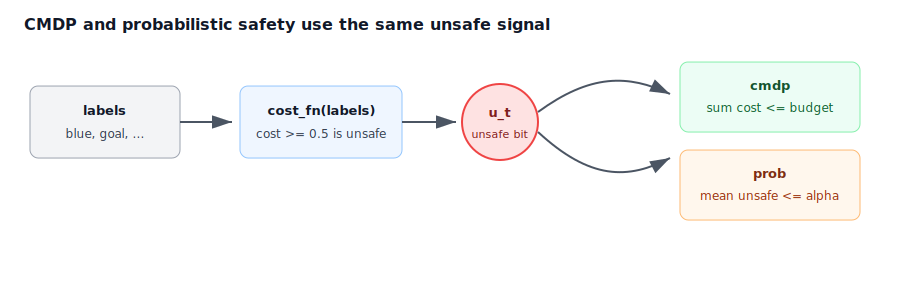

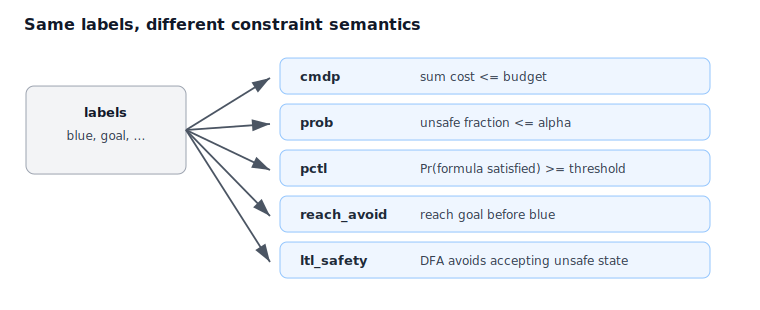

In [10]:
display(SVG(render_cmdp_prob_svg()))
display(SVG(render_constraint_semantics_svg()))


## Rollout helper

The helper records a compact final row for each constraint. `LTL_SAFETY` augments observations with automaton state, so the observation simplifier handles dictionaries as well as integers.

In [11]:
def simplify_obs(obs):
    if isinstance(obs, dict):
        return {key: simplify_obs(value) for key, value in obs.items()}
    try:
        return int(obs)
    except (TypeError, ValueError):
        return obs

def run_constraint(name, *, seed, actions, max_episode_steps=40):
    env = build_constraint_env(name, max_episode_steps=max_episode_steps)
    obs, info = env.reset(seed=seed)
    rows = [
        {
            "event": "reset",
            "obs": simplify_obs(obs),
            "labels": sorted(info["labels"]),
            "constraint": info["constraint"],
            "automaton_state": info.get("automaton_state"),
        }
    ]

    for step, action in enumerate(actions, start=1):
        obs, reward, terminated, truncated, info = env.step(action)
        rows.append(
            {
                "event": f"step_{step}",
                "action": ACTION_NAMES[action],
                "obs": simplify_obs(obs),
                "reward": float(reward),
                "terminated": bool(terminated),
                "truncated": bool(truncated),
                "labels": sorted(info["labels"]),
                "constraint": info["constraint"],
                "automaton_state": info.get("automaton_state"),
            }
        )
        if terminated or truncated:
            break

    env.close()
    return rows

def final_metrics_for(script):
    return {
        name: run_constraint(name, seed=script["seed"], actions=script["actions"])[-1]
        for name in CONSTRAINT_NAMES
    }


## Unsafe script: reach blue

With seed `1`, actions `[2, 2, 2, 2]` reach the blue state. Compare how each constraint reports the same labelled event.

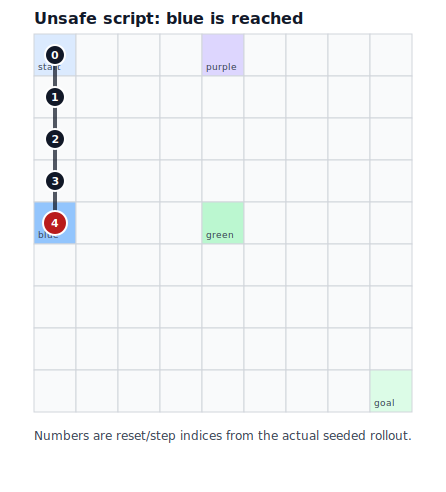

{'CMDP': {'action': 'down',
          'automaton_state': None,
          'constraint': {'episode': {'cum_cost': 1.0, 'satisfied': 0.0},
                         'step': {'cost': 1.0,
                                  'cum_cost': 1.0,
                                  'violation': 1.0},
                         'type': 'cmdp'},
          'event': 'step_4',
          'labels': ['blue'],
          'obs': 36,
          'reward': 0.0,
          'terminated': False,
          'truncated': False},
 'LTL_SAFETY': {'action': 'down',
                'automaton_state': 1,
                'constraint': {'episode': {'cum_unsafe': 1.0, 'satisfied': 0.0},
                               'step': {'cost': 1.0, 'violation': 1.0},
                               'type': 'ltl_safety'},
                'event': 'step_4',
                'labels': ['blue'],
                'obs': {'automaton': 1, 'orig': 36},
                'reward': 0.0,
                'terminated': False,
                'truncated': Fals

In [ ]:
unsafe_trace = run_constraint("CMDP", seed=UNSAFE_SCRIPT["seed"], actions=UNSAFE_SCRIPT["actions"])
display(SVG(render_grid_trace_svg(unsafe_trace, "Unsafe script: blue is reached")))

unsafe_results = final_metrics_for(UNSAFE_SCRIPT)
pprint(unsafe_results)

assert unsafe_trace[-1]["obs"] == BLUE_STATE
assert unsafe_results["CMDP"]["constraint"]["step"]["cost"] == 1.0
assert unsafe_results["PROB"]["constraint"]["step"]["violation"] == 1.0
assert unsafe_results["PCTL"]["constraint"]["step"]["violation"] == 1.0
assert unsafe_results["REACH_AVOID"]["constraint"]["step"]["violation"] is True
assert unsafe_results["LTL_SAFETY"]["constraint"]["step"]["violation"] == 1.0


## Goal script: reach goal without blue

With seed `4`, actions `[2] * 8 + [1] * 8` reach the goal state without visiting blue. Reach-avoid should be satisfied, and the never-blue LTL monitor should remain safe.

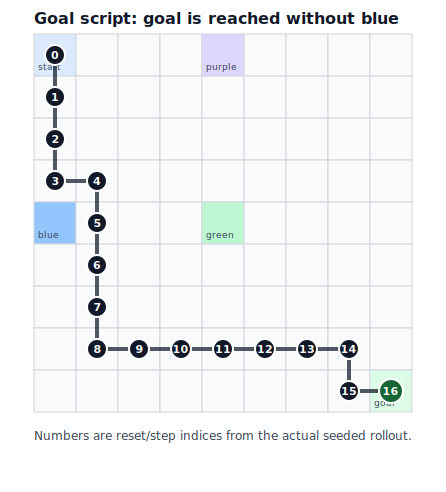

{'CMDP': {'action': 'right',
          'automaton_state': None,
          'constraint': {'episode': {'cum_cost': 0.0, 'satisfied': 1.0},
                         'step': {'cost': 0.0,
                                  'cum_cost': 0.0,
                                  'violation': 0.0},
                         'type': 'cmdp'},
          'event': 'step_16',
          'labels': ['goal'],
          'obs': 80,
          'reward': 1.0,
          'terminated': True,
          'truncated': False},
 'LTL_SAFETY': {'action': 'right',
                'automaton_state': 0,
                'constraint': {'episode': {'cum_unsafe': 0.0, 'satisfied': 1.0},
                               'step': {'cost': 0.0, 'violation': 0.0},
                               'type': 'ltl_safety'},
                'event': 'step_16',
                'labels': ['goal'],
                'obs': {'automaton': 0, 'orig': 80},
                'reward': 1.0,
                'terminated': True,
                'truncated': Fa

In [14]:
goal_trace = run_constraint("CMDP", seed=GOAL_SCRIPT["seed"], actions=GOAL_SCRIPT["actions"])
display(SVG(render_grid_trace_svg(goal_trace, "Goal script: goal is reached without blue")))

goal_results = final_metrics_for(GOAL_SCRIPT)
pprint(goal_results)

assert goal_trace[-1]["obs"] == GOAL_STATE
assert goal_results["CMDP"]["constraint"]["episode"]["satisfied"] == 1.0
assert goal_results["PROB"]["constraint"]["episode"]["satisfied"] == 1.0
assert goal_results["PCTL"]["constraint"]["episode"]["satisfied"] == 1.0
assert goal_results["REACH_AVOID"]["constraint"]["episode"]["satisfied"] == 1.0
assert goal_results["LTL_SAFETY"]["constraint"]["episode"]["satisfied"] == 1.0
assert goal_results["REACH_AVOID"]["labels"] == ["goal"]


## How to read the differences

- `CMDP` accumulates scalar cost and checks it against a budget.
- `PROB` tracks the empirical fraction of unsafe observations and checks it against `alpha`.
- `PCTL` is intended to evaluate whether a bounded PCTL formula's satisfaction probability meets its threshold.
- `REACH_AVOID` separately tracks whether the target was reached and whether the avoid label was ever seen.
- `LTL_SAFETY` advances a DFA and reports violations when the automaton enters an accepting unsafe state.

The raw environment labels are the same. The constraint determines how those labels become safety state and metrics.